In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [2]:
import pandas as pd
iris = load_iris()
iris_data = iris.data
iris_label = iris.target
print('iris target값:', iris_label)
print('iris target명:', iris.target_names)
iris_df = pd.DataFrame(data=iris_data, columns = iris.feature_names)
iris_df['label'] = iris.target
iris_df.head(3)

iris target값: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
iris target명: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


In [3]:
X_train, X_test, y_train, y_test = train_test_split(iris_data, iris_label, test_size = 0.2, random_state = 11)
print(X_train[0])

[5.1 3.5 1.4 0.2]


In [4]:
# 학습 / 예측
dt_clf = DecisionTreeClassifier(random_state = 11)
dt_clf.fit(X_train, y_train)
pred = dt_clf.predict(X_test)

# 평가
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, pred)
print('예측 정확도: {0:.4f}'.format(acc))

예측 정확도: 0.9333


In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train, y_train)
pred = dt_clf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

print('정확도: ', accuracy_score(y_test, pred))
print('오차행렬: ', confusion_matrix(y_test, pred))
print('정밀도: ', precision_score(y_test, pred))
print('재현율: ', recall_score(y_test, pred))

정확도:  0.9122807017543859
오차행렬:  [[44  3]
 [ 7 60]]
정밀도:  0.9523809523809523
재현율:  0.8955223880597015


In [ ]:
cancer.target_names     # malignant: 악성, benign: 양성

array(['malignant', 'benign'], dtype='<U9')

In [ ]:
dt_clf.predict_proba(X_test[:5])        
# proba는 probability의 약자, predict_proba는 예측 확률을 반환
# decisontree로 해서 0과 1로 나오지만, 다른 모델을 쓰면 0.8, 0.2 이런식으로 확률로 나옴

array([[1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.]])

In [ ]:
from sklearn.linear_model import LogisticRegression     

lr_clf = LogisticRegression()   # 로지스틱 회귀 모델 생성
lr_clf.fit(X_train, y_train)    # 학습
pred = lr_clf.predict(X_test)   # 예측
pred_proba = lr_clf.predict_proba(X_test[:5])       # 예측 확률 출력

print('정확도: ', accuracy_score(y_test, pred))
print('오차행렬: ', confusion_matrix(y_test, pred))
print('정밀도: ', precision_score(y_test, pred))
print('재현율: ', recall_score(y_test, pred))

정확도:  0.956140350877193
오차행렬:  [[46  1]
 [ 4 63]]
정밀도:  0.984375
재현율:  0.9402985074626866


c:\Users\samsung1\git_project\samsung_practice\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
pred_proba

array([[9.94226113e-01, 5.77388685e-03],
       [2.46913821e-02, 9.75308618e-01],
       [1.55132100e-03, 9.98448679e-01],
       [1.72160360e-01, 8.27839640e-01],
       [8.10800930e-05, 9.99918920e-01]])

In [ ]:
# 임계값 조정하기
# 이 방법은 많이 쓰이지 않음
from sklearn.preprocessing import Binarizer
X = [[ 1, -1, 2],       # 예시 데이터
[ 2, 0, 0],
[ 0, 1.1, 1.2]]
binarizer = Binarizer(threshold= 1.1)
print(binarizer.fit_transform(X))

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]


In [ ]:
# 임계값 조정하기
# 다른 방법
import numpy as np
(np.array(X) > 1.1).astype(int)

array([[0, 0, 1],
       [1, 0, 0],
       [0, 0, 1]])

In [ ]:
# 분류 평가 지표
# 정확도, 오차행렬, 정밀도, 재현율, F1 스코어, ROC-AUC

# 정확도: 잘 맞추는지
# 오차행렬: 정답을 어떻게 예측해서 맞추고 틀렸는지를 표현
# 정밀도: 예측을 positive > 얼마나 맞췄냐
# 재현율: 실제값이 Pos > 얼마나 맞췄냐
# 임계값 조정 통해서 정밀도나 재현율의 값을 올리거나 내리거나 할 수 있다.
# F1스코어: 정밀도, 재현율이 밸런스있게 높은 점수가 나오는데
# ROC-AUC: 분류 임계값과 무관한 클래스 구분 능력
# ROD-AUC만 predict_proba의 확률값을 넣어서 계산해야된다.


In [14]:
# 결정 트리 실습
# 와인 데이터 실습

from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['class'] = wine.target
print(wine.target_names)
df.head()

['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [ ]:
# 학습 데이터 준비
from sklearn.model_selection import train_test_split
X_data = df.iloc[:, :-1]
y_data = df.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data,test_size=0.2 , random_state= 156)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(142, 13) (36, 13)
(142,) (36,)


In [23]:
# 학습 / 예측 / 평가
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

dt_clf = DecisionTreeClassifier(random_state=156)
dt_clf.fit(X_train , y_train)
pred = dt_clf.predict(X_test)
accuracy = accuracy_score(y_test , pred)
print('결정 트리 예측 정확도: {0:.4f}'.format(accuracy))

결정 트리 예측 정확도: 0.9444


In [19]:
confusion_matrix(y_test, pred)

array([[11,  0,  0],
       [ 1, 12,  1],
       [ 0,  0, 11]])

In [ ]:
print(precision_score(y_test, pred, average='micro'))
print(recall_score(y_test, pred, average='micro'))
print(f1_score(y_test, pred, average='micro'))

# 결과가 똑같이 나오는 것은 정상이다

0.9444444444444444
0.9444444444444444
0.9444444444444444


In [ ]:
from sklearn.metrics import roc_auc_score
pred_proba = dt_clf.predict_proba(X_test)
roc_auc_score(y_test, pred_proba, multi_class='ovo', average='weighted')


np.float64(0.9627976190476191)

In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        11
           1       1.00      0.86      0.92        14
           2       0.92      1.00      0.96        11

    accuracy                           0.94        36
   macro avg       0.94      0.95      0.95        36
weighted avg       0.95      0.94      0.94        36



In [ ]:
# macro
(0.92 + 1.00 + 0.92) / 3

# weighted
(11 / 36) * 0.92 + (14 / 36) * 1.00 + (11 / 36) * 0.92

# ovo: One Vs One

# ovr: One Vs Rest ( 일 대 다 )

In [ ]:
# GridSearchCV
from sklearn.model_selection import GridSearchCV

parameters = {'criterion':['gini', 'entropy'],
              'max_depth':[None, 2, 3, 5, 7],
              'min_samples_split':[2, 3, 5, 7],
              'min_samples_leaf':[1, 3, 5, 7]
              }

query = GridSearchCV(dt_clf, param_grid = parameters, cv = 5)
grid_dt = GridSearchCV(dt_clf, param_grid = parameters, cv = 5)
grid_dt.fit(X_train, y_train)

scores_df = pd.DataFrame(grid_dt.cv_results_)
scores_df[['params', 'mean_test_score', 'rank_test_score']]

,params,mean_test_score,rank_test_score
0,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.851478,101
1,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.851478,101
2,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.858621,68
3,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.865517,65
4,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.858621,68
...,...,...,...
155,"{'criterion': 'entropy', 'max_depth': 7, 'min_...",0.858621,68
156,"{'criterion': 'entropy', 'max_depth': 7, 'min_...",0.865764,33
157,"{'criterion': 'entropy', 'max_depth': 7, 'min_...",0.865764,33
158,"{'criterion': 'entropy', 'max_depth': 7, 'min_...",0.865764,33


In [18]:
print('GridSearchCV 최적 파라미터:', grid_dt.best_params_)
print(f'GridSearchCV 최고 정확도: {grid_dt.best_score_:.4f}')


GridSearchCV 최적 파라미터: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
GridSearchCV 최고 정확도: 0.8936


In [35]:
# 피마 인디언 당뇨병 예측
# 필요 라이브러리 호출

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import f1_score, confusion_matrix, precision_recall_curve, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [36]:
# 데이터 불러오기
diabetes_data = pd.read_csv('data/diabetes.csv')
print(diabetes_data['Outcome'].value_counts())
diabetes_data.head(3)

Outcome
0    500
1    268
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [37]:
# 데이터 살펴보기
diabetes_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
diabetes_data.describe()

# pregnancies의 min값을 제외한 나머지 min값이 0인 컬럼들은 모두 이상치로 간주

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [44]:
# 데이터 학습 / 예측 / 평가

X = diabetes_data.iloc[:, :-1]
y = diabetes_data.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 156, stratify = y)        # stratify는 y의 비율을 train과 test에 동일하게 나눠주는 것
                     # y를 넣는 이유는 y의 비율을 train과 test에 동일하게 나눠주기 위해서


In [46]:
y_test.value_counts()

Outcome
0    100
1     54
Name: count, dtype: int64

In [52]:
lr_clf = LogisticRegression(solver = 'liblinear')
lr_clf.fit(X_train, y_train)
pred = lr_clf.predict(X_test)
pred_proba = lr_clf.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test , pred)
confusion = confusion_matrix(y_test, pred)
precision = precision_score(y_test , pred)
recall = recall_score(y_test , pred)
f1 = f1_score(y_test, pred)
roc = roc_auc_score(y_test, pred_proba)
print('오차 행렬')
print(confusion)
print(f'정확도: {accuracy:.4f}, 정밀도: {precision:.4f}, 재현율: {recall:.4f}, F1: {f1:.4f}, ROC_AUC: {roc:.4f}')

오차 행렬
[[87 13]
 [22 32]]
정확도: 0.7727, 정밀도: 0.7111, 재현율: 0.5926, F1: 0.6465, ROC_AUC: 0.8083


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train, y_train)
pred = dt_clf.predict(X_test)
pred_proba = dt_clf.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, pred)
confusion = confusion_matrix(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
roc = roc_auc_score(y_test, pred_proba)
print('오차 행렬')
print(confusion)
print(f'정확도: {accuracy:.4f}, 정밀도: {precision:.4f}, 재현율: {recall:.4f}, F1: {f1:.4f}, ROC_AUC: {roc:.4f}')

오차 행렬
[[76 24]
 [22 32]]
정확도: 0.7013, 정밀도: 0.5714, 재현율: 0.5926, F1: 0.5818, ROC_AUC: 0.6763


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier()
rf_clf.fit(X_train, y_train)
pred = rf_clf.predict(X_test)
pred_proba = rf_clf.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, pred)
confusion = confusion_matrix(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
roc = roc_auc_score(y_test, pred_proba)
print('오차 행렬')
print(confusion)
print(f'정확도: {accuracy:.4f}, 정밀도: {precision:.4f}, 재현율: {recall:.4f}, F1: {f1:.4f}, ROC_AUC: {roc:.4f}')

오차 행렬
[[86 14]
 [24 30]]
정확도: 0.7532, 정밀도: 0.6818, 재현율: 0.5556, F1: 0.6122, ROC_AUC: 0.8237


In [ ]:
# 모델 성능 비교

# LogisticRegression(로지스틱 회귀)
# 오차 행렬
# [[87 13]
#  [22 32]]
# 정확도: 0.7727, 정밀도: 0.7111, 재현율: 0.5926, F1: 0.6465, ROC_AUC: 0.8083


# DecisionTreeClassifier(결정 트리)
# 오차 행렬
# [[76 24]
#  [22 32]]
# 정확도: 0.7013, 정밀도: 0.5714, 재현율: 0.5926, F1: 0.5818, ROC_AUC: 0.6763


# RandomForestClassifier(랜덤 포레스트)
# 오차 행렬
# [[86 14]
#  [24 30]]
# 정확도: 0.7532, 정밀도: 0.6818, 재현율: 0.5556, F1: 0.6122, ROC_AUC: 0.8237

In [54]:
# 피쳐 다시 살펴보기
diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


(array([ 5.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,
         0.,  0.,  3.,  0.,  1.,  1.,  1.,  1.,  3.,  4.,  4.,  6.,  4.,
         7., 12.,  9., 17., 10., 15., 20., 16., 20., 17., 20., 26., 22.,
        19., 25., 25., 20., 18., 21., 18., 17., 17., 21., 25., 14., 25.,
        12., 10., 10., 16., 13., 10., 11., 12., 16.,  5.,  9.,  6., 11.,
         5., 10.,  4.,  9.,  7.,  6.,  5.,  5.,  7.,  4.,  3.,  6., 10.,
         4.,  3.,  5.,  6.,  2.,  2.,  5.,  7.,  2.]),
 array([  0.  ,   1.99,   3.98,   5.97,   7.96,   9.95,  11.94,  13.93,
         15.92,  17.91,  19.9 ,  21.89,  23.88,  25.87,  27.86,  29.85,
         31.84,  33.83,  35.82,  37.81,  39.8 ,  41.79,  43.78,  45.77,
         47.76,  49.75,  51.74,  53.73,  55.72,  57.71,  59.7 ,  61.69,
         63.68,  65.67,  67.66,  69.65,  71.64,  73.63,  75.62,  77.61,
         79.6 ,  81.59,  83.58,  85.57,  87.56,  89.55,  91.54,  93.53,
  

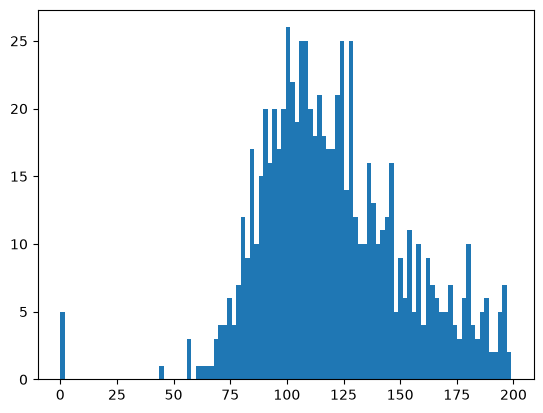

In [ ]:
# 피쳐 다시 살펴보기
plt.hist(diabetes_data['Glucose'], bins = 100)

In [ ]:
zero_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
total_count = diabetes_data['Glucose'].count()
for feature in zero_features:
    zero_count = diabetes_data[ diabetes_data [feature] == 0][feature].count()
    print(f'{feature} 0 건수는 {zero_count}, 퍼센트는 {100 * zero_count / total_count:.2f} %')

# 의학적으로 인슐린 수치가 0인 경우는 없기 때문에, 
# 0으로 되어 있는 값들은 이상치로 간주하고, 평균값으로 대체하는 것이 좋다.

Glucose 0 건수는 5, 퍼센트는 0.65 %
BloodPressure 0 건수는 35, 퍼센트는 4.56 %
SkinThickness 0 건수는 227, 퍼센트는 29.56 %
Insulin 0 건수는 374, 퍼센트는 48.70 %
BMI 0 건수는 11, 퍼센트는 1.43 %
